In [1]:
#!pip install -q unsloth boto3
#!pip install -q --no-deps trl peft accelerate bitsandbytes datasets

In [2]:
import torch
assert torch.cuda.is_available(), "GPU is not detected! This script requires a GPU to run."
print(f"Using GPU: {torch.cuda.get_device_name(0)}")


Using GPU: NVIDIA RTX 5000 Ada Generation


In [3]:
import os

PROJECT_DIR = "./cloud_project"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
FINAL_DIR = f"{PROJECT_DIR}/final_lora"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

print("Checkpoint dir:", CHECKPOINT_DIR)

Checkpoint dir: ./cloud_project/checkpoints


In [4]:
import boto3
import time
import os
from botocore import UNSIGNED
from botocore.config import Config

BUCKET_NAME = '25tfgf-ai-medical'
S3_FOLDER   = 'processed/'
LOCAL_DIR   = './data/processed/'

s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

def download_s3_folder(bucket: str, s3_prefix: str, local_base: str) -> None:
    """Download all objects under s3_prefix into local_base, preserving structure."""
    paginator = s3.get_paginator('list_objects_v2')
    print(f"Searching for files in s3://{bucket}/{s3_prefix}...")

    for page in paginator.paginate(Bucket=bucket, Prefix=s3_prefix):
        if 'Contents' not in page:
            print("No files found! Check if 'Block Public Access' is OFF and Bucket Policy is set.")
            return

        for obj in page['Contents']:
            s3_key       = obj['Key']
            expected_size = obj['Size']
            relative_path = os.path.relpath(s3_key, s3_prefix)
            local_file_path = os.path.join(local_base, relative_path)

            if s3_key.endswith('/'):
                continue

            os.makedirs(os.path.dirname(local_file_path), exist_ok=True)
            
            if os.path.exists(local_file_path):
                local_size = os.path.getsize(local_file_path)
                if local_size == expected_size:
                    print(f"Skipped (Already exists): {local_file_path}")
                    continue
            # -----------------------------------------------

            print(f"Downloading: {s3_key} -> {local_file_path}")
            for attempt in range(5):
                try:
                    s3.download_file(bucket, s3_key, local_file_path)
                    break
                except PermissionError as e:
                    if attempt == 4:
                        raise e
                    print(f"PermissionError on attempt {attempt+1}, retrying in 2 seconds...")
                    time.sleep(2)

    print("Download complete.")


In [5]:
import sys
import datasets.utils._dill

original_batch = datasets.utils._dill.Pickler._batch_setitems
def _new_batch_setitems(self, items, obj=None):
    return original_batch(self, items)
datasets.utils._dill.Pickler._batch_setitems = _new_batch_setitems


In [6]:
from datasets import load_dataset

LOCAL_DATA_PATH = './data/processed'

dataset = load_dataset("parquet", data_files={
    "train":      f"{LOCAL_DATA_PATH}/split=train/*.parquet",
    "validation": f"{LOCAL_DATA_PATH}/split=val/*.parquet",
    "test":       f"{LOCAL_DATA_PATH}/split=test/*.parquet",
})

print(dataset)
print(dataset["train"][0])

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question_parsed', 'context_parsed', 'prompt'],
        num_rows: 4641118
    })
    validation: Dataset({
        features: ['id', 'question_parsed', 'context_parsed', 'prompt'],
        num_rows: 580699
    })
    test: Dataset({
        features: ['id', 'question_parsed', 'context_parsed', 'prompt'],
        num_rows: 581330
    })
})
{'id': 0, 'question_parsed': 'What isoform is a locus for inherited spinocerebellar at', 'context_parsed': "Rapid firing of cerebellar Purkinje neurons is facilitated in part by a voltage-gated Na+ (NaV) 'resurgent' current, which allows renewed Na+ influx during membrane repolarization. Resurgent current results from unbinding of a blocking particle that competes with normal channel inactivation. The underlying molecular components contributing to resurgent current have not been fully identified. Here, we show that the NaV channel auxiliary subunit FGF14 'b' isoform, a locus for inherited spi

In [7]:
TRAIN_SIZE = min(50000, len(dataset["train"]))
EVAL_SIZE = min(2500, len(dataset["validation"]))

train_data = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
eval_data = dataset["validation"].shuffle(seed=42).select(range(EVAL_SIZE))

print("Train examples:", len(train_data))
print("Eval examples:", len(eval_data))

Train examples: 50000
Eval examples: 2500


In [8]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512
dtype = None
load_in_4bit = True

model_name = "unsloth/Llama-3.2-1B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="cuda",
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.ppov2_trainer: Direct module loading failed for UnslothPPOv2Trainer: duplicate argument 'kwargs' in function definition (UnslothPPOv2Trainer.py, line 369)


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.9. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [9]:
import re

SENTENCE_SPLIT = re.compile(r'(?<=[.!?])\s+')
WORD_FIND = re.compile(r'\b\w+\b')

STOPWORDS = frozenset({"the", "a", "an", "is", "are", "was", "were", "be", "been",
                       "what", "which", "who", "how", "why", "does", "do", "did",
                       "can", "could", "would", "should", "will", "shall", "have",
                       "has", "had", "this", "that", "these", "those", "in", "on",
                       "at", "to", "for", "of", "with", "by", "from", "as", "and",
                       "or", "but", "not", "no", "yes", "may", "might", "must"})

def extract_relevant_sentence(question, context):
    """Find the most relevant sentence AND the following sentences to provide actual advice."""
    sentences = [s.strip() for s in SENTENCE_SPLIT.split(context) if len(s.strip()) > 15]
    if not sentences:
        return context[:400] + "..." if len(context) > 400 else context

    q_words = set(WORD_FIND.findall(question.lower())) - STOPWORDS
    if not q_words:
        return " ".join(sentences[:2])

    best_idx = 0
    best_score = -1

    for i, sent in enumerate(sentences):
        sent_words = set(WORD_FIND.findall(sent.lower()))
        score = len(q_words & sent_words)
        
        medical_keywords = ["suggest", "indicate", "treatment", "diagnosis", "recommend", "should", "therapy", "prescribe", "condition"]
        if any(w in sent.lower() for w in medical_keywords):
            score += 2.0  
            
        if score > best_score:
            best_score = score
            best_idx = i

    end_idx = min(len(sentences), best_idx + 3)
    best_chunk = " ".join(sentences[best_idx:end_idx])

    if len(best_chunk) > 600:
        best_chunk = best_chunk[:600].rsplit(" ", 1)[0] + "..."

    return best_chunk


In [10]:
def rewrite_to_second_person(text):
    """
    Convert third-person clinical text to second-person direct response.
    Handles verb agreement and common medical phrasing.
    """
    replacements = [
        (r'\b[Tt]his patient has been experiencing\b', 'You have been experiencing'),
        (r'\b[Tt]he patient has been experiencing\b', 'You have been experiencing'),
        (r'\b[Tt]his patient has experienced\b', 'You have experienced'),
        (r'\b[Tt]he patient has experienced\b', 'You have experienced'),
        (r'\b[Tt]his patient presents with\b', 'You have'),
        (r'\b[Tt]he patient presents with\b', 'You have'),
        (r'\b[Tt]his patient presented with\b', 'You had'),
        (r'\b[Tt]he patient presented with\b', 'You had'),
        (r'\b[Tt]his patient is experiencing\b', 'You are experiencing'),
        (r'\b[Tt]he patient is experiencing\b', 'You are experiencing'),
        (r'\b[Tt]his patient was diagnosed\b', 'You were diagnosed'),
        (r'\b[Tt]he patient was diagnosed\b', 'You were diagnosed'),
        (r'\b[Tt]his patient should be monitored\b', 'You should be checked'),
        (r'\b[Tt]he patient should be monitored\b', 'You should be checked'),
        (r'\b[Tt]his patient should be\b', 'You should be'),
        (r'\b[Tt]he patient should be\b', 'You should be'),
        (r'\b[Tt]his patient may have\b', 'You may have'),
        (r'\b[Tt]he patient may have\b', 'You may have'),
        (r'\b[Tt]his patient might have\b', 'You might have'),
        (r'\b[Tt]he patient might have\b', 'You might have'),

        (r'\b[Tt]he patient\b', 'you'),
        (r'\b[Tt]his patient\b', 'you'),
        (r'\b[Pp]atient\b', 'you'),
        (r'\b[Hh]e has\b', 'You have'),
        (r'\b[Ss]he has\b', 'You have'),
        (r'\b[Hh]e is\b', 'You are'),
        (r'\b[Ss]he is\b', 'You are'),
        (r'\b[Hh]e was\b', 'You were'),
        (r'\b[Ss]he was\b', 'You were'),
        (r'\b[Hh]e\b', 'you'),
        (r'\b[Ss]he\b', 'you'),
        (r'\b[Hh]is\b', 'your'),
        (r'\b[Hh]er\b', 'your'),  
        (r'\b[Hh]im\b', 'you'),

        (r'\byou has\b', 'you have'),
        (r'\byou is\b', 'you are'),
        (r'\byou was\b', 'you were'),
        (r'\byou does\b', 'you do'),
        (r'\byou has had\b', 'you have had'),

        (r'\b[Ww]e show that\s*', ''),
        (r'\b[Ww]e demonstrate that\s*', ''),
        (r'\b[Oo]ur findings suggest\s*', 'This suggests '),
        (r'\b[Tt]hese data suggest\s*', 'This suggests '),
        (r'\b[Ii]n conclusion,\s*', ''),
        (r'\b[Ii]nterestingly,\s*', ''),
        (r'\b[Nn]otably,\s*', ''),
        (r'\b[Tt]ogether,\s*', ''),
        (r'\b[Hh]ere, we\s*', ''),
    ]

    for pattern, replacement in replacements:
        text = re.sub(pattern, replacement, text)

    text = re.sub(r'\s+', ' ', text).strip()
    text = text.strip(',. ')

    if text:
        text = text[0].upper() + text[1:]

    if text and text[-1] not in '.!?':
        text += '.'

    return text

In [11]:
SYSTEM_PROMPT = (
    "You are a helpful medical assistant. The user describes their symptoms or asks a medical question. "
    "Respond directly to THEM using 'you' and 'your'. Be concise (1-3 sentences). "
    "Do NOT describe patients in the third person. Do NOT use clinical note style. "
    "Do NOT use bullet points or lists. Write like you're talking to the person asking."
)

def formatting_prompts_func(examples):
    questions = examples["question_parsed"]
    contexts = examples["context_parsed"]
    texts = []

    for question, context in zip(questions, contexts):
        raw_answer = extract_relevant_sentence(question, context)

        answer = rewrite_to_second_person(raw_answer)

        answer = answer.replace('- ', '').replace('• ', '')

        if len(answer) < 20:
            answer = "You should discuss these symptoms with your doctor for proper evaluation."

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer},
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)

    return {"text": texts}


train_data = train_data.map(
    formatting_prompts_func,
    batched=True,
    num_proc=1,
    remove_columns=train_data.column_names,
)

eval_data = eval_data.map(
    formatting_prompts_func,
    batched=True,
    num_proc=1,
    remove_columns=eval_data.column_names,
)

print("Sample formatted text:")
print(train_data[0]["text"][:800])
print("\n" + "="*80)
print("Sample answer only:")
sample = train_data[0]["text"]
if "assistant" in sample:
    print(sample.split("assistant")[-1].strip()[:500])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Sample formatted text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 04 May 2026

You are a helpful medical assistant. The user describes their symptoms or asks a medical question. Respond directly to THEM using 'you' and 'your'. Be concise (1-3 sentences). Do NOT describe patients in the third person. Do NOT use clinical note style. Do NOT use bullet points or lists. Write like you're talking to the person asking.<|eot_id|><|start_header_id|>user<|end_header_id|>

What is the name of the team that developed the concept of the Designated Donor Nurse?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

To that end, we developed the concept of the Designated Donor Nurse to care for and advocate for live liver donors during the inpatient stay and 

Sample answer only:
<|end_header_id|>

To that end, we developed the concept of the Designated Donor Nurse to care for and advocate for live liver donors during the inpatient 

In [12]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                   "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


In [13]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
from pathlib import Path

CHECKPOINT_DIR = Path(CHECKPOINT_DIR)
FINAL_DIR = Path(FINAL_DIR)

def get_last_checkpoint(output_dir):
    output_dir = Path(output_dir)
    checkpoints = list(output_dir.glob("checkpoint-*"))
    if not checkpoints:
        return None
    return str(max(checkpoints, key=lambda p: int(p.name.split("-")[-1])))

def final_model_exists(final_dir):
    final_dir = Path(final_dir)

    adapter_config = final_dir / "adapter_config.json"
    adapter_safetensors = final_dir / "adapter_model.safetensors"
    adapter_bin = final_dir / "adapter_model.bin"

    return adapter_config.exists() and (
        adapter_safetensors.exists() or adapter_bin.exists()
    )

if final_model_exists(FINAL_DIR):
    print(f" Final LoRA model already exists in: {FINAL_DIR}")
    print("⏭ Skipping training model found.")

    SKIP_TRAIN = True
    trainer_stats = None
    trainer = None

else:
    print(" Final model not found. Starting / resuming training...")

    SKIP_TRAIN = False

    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        dataset_text_field="text",
        max_seq_length=1024,
        dataset_num_proc=2,
        packing=True,

        args=TrainingArguments(
            per_device_train_batch_size=4,
            gradient_accumulation_steps=4,

            num_train_epochs=1,
            max_steps=-1,

            learning_rate=2e-5,
            warmup_ratio=0.03,
            lr_scheduler_type="cosine",

            weight_decay=0.01,
            max_grad_norm=1.0,

            fp16=not is_bfloat16_supported(),
            bf16=is_bfloat16_supported(),

            logging_steps=50,
            eval_strategy="steps",
            eval_steps=500,

            save_strategy="steps",
            save_steps=1000,
            save_total_limit=2,

            optim="adamw_8bit",

            seed=3407,
            output_dir=str(CHECKPOINT_DIR),
            report_to="none",
        ),
    )

    last_checkpoint = get_last_checkpoint(CHECKPOINT_DIR)
    print("Last checkpoint:", last_checkpoint)

    trainer_stats = trainer.train(
        resume_from_checkpoint=last_checkpoint if last_checkpoint else None
    )

    trainer.save_model(str(FINAL_DIR))
    tokenizer.save_pretrained(str(FINAL_DIR))

    print(f" Final model saved to: {FINAL_DIR}")

 Final LoRA model already exists in: cloud_project\final_lora
⏭ Skipping training model found.


In [14]:
if trainer is not None:
    trainer.save_model(str(FINAL_DIR))
    tokenizer.save_pretrained(str(FINAL_DIR))
    print(f"Model saved to {FINAL_DIR}")
else:
    print("Training was skipped. Final model already exists.")

Training was skipped. Final model already exists.


In [15]:
from transformers import GenerationConfig

model = FastLanguageModel.for_inference(model)

test_questions = [
    "I am a 45-year-old male. I have been experiencing severe chest pain radiating to my left arm, accompanied by shortness of breath and sweating for the past 2 hours. What could be causing these symptoms and how urgent is this?",
    "My doctor prescribed me Metformin 500mg twice daily for Type 2 Diabetes. What are the common and serious side effects I should watch out for?",
    "I am a 32-year-old non-smoker with no prior lung conditions. I have had a dry, persistent cough for 3 weeks with mild fatigue but no fever. What are the possible causes and when should I seek medical attention?",
]

for question in test_questions:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        return_tensors="pt",
        add_generation_prompt=True,
        padding=True,
    ).to("cuda")

    attention_mask = inputs != tokenizer.pad_token_id

    outputs = model.generate(
        inputs,
        attention_mask=attention_mask,
        max_new_tokens=120,
        temperature=0.4,
        top_p=0.85,
        repetition_penalty=1.15,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=False)

    if "<|start_header_id|>assistant<|end_header_id|>" in response:
        response = response.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()
    elif "assistant" in response:
        parts = response.split("assistant")
        response = parts[-1].strip()

    response = response.replace("<|eot_id|>", "").replace("<|end_of_text|>", "").strip()

    print("=" * 80)
    print(f"QUESTION: {question[:80]}...")
    print(f"ANSWER: {response[:500]}")
    print()

QUESTION: I am a 45-year-old male. I have been experiencing severe chest pain radiating to...
ANSWER: It sounds like your chest pains may be related to an acute coronary syndrome, which can cause intense chest pain that feels like it's spreading to other areas of your body. Given the severity of your symptoms, including shortness of breath and sweating, it's essential to get checked out right away.

Your condition seems to require immediate attention, so please go see a doctor as soon as possible. If you're not already at a hospital or clinic, try to find one nearby where you can receive emergen

QUESTION: My doctor prescribed me Metformin 500mg twice daily for Type 2 Diabetes. What ar...
ANSWER: I'm glad your doctor is helping manage your diabetes, but it's great that you're paying attention to potential side effects of medication.

When taking Metformin, some people may experience digestive issues such as nausea, diarrhea, or stomach cramps. You might also notice changes in your ener

ℹ Training was skipped.
 Loaded previous training log: cloud_project\training_log.csv


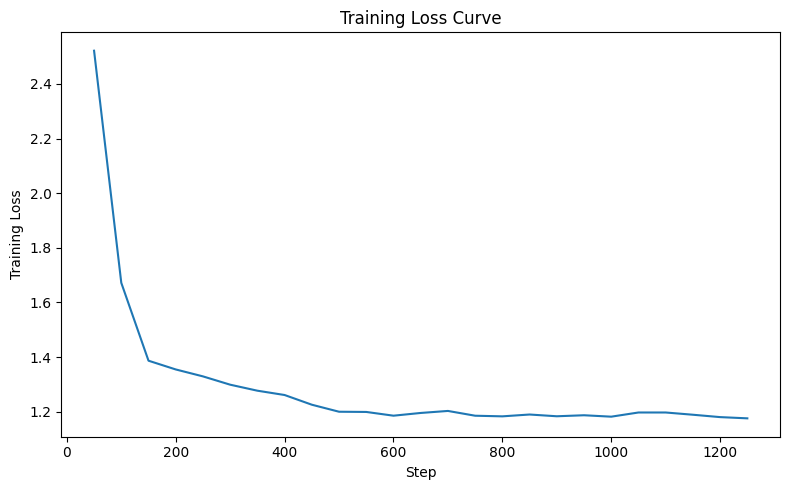

 Saved: cloud_project\training_loss_curve.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(PROJECT_DIR)

log_path = PROJECT_DIR / "training_log.csv"
fig_path = PROJECT_DIR / "training_loss_curve.png"

# الحالة الأولى: التدريب اشتغل فعلاً في نفس السيشن
if "trainer" in globals() and trainer is not None:
    logs = trainer.state.log_history
    log_df = pd.DataFrame(logs)

    log_df.to_csv(log_path, index=False)
    print(" Training log saved:", log_path)

# الحالة الثانية: التدريب اتعمله Skip، فهنقرأ اللوج القديم لو موجود
elif log_path.exists():
    log_df = pd.read_csv(log_path)
    print("ℹ Training was skipped.")
    print(" Loaded previous training log:", log_path)

# الحالة الثالثة: التدريب اتعمله Skip ومفيش لوج قديم
else:
    log_df = pd.DataFrame()
    print(" Training was skipped and no previous training_log.csv was found.")
    print("No loss values available.")

# رسم الـ Training Loss
if not log_df.empty and "loss" in log_df.columns:
    loss_df = log_df.dropna(subset=["loss"])

    if not loss_df.empty:
        plt.figure(figsize=(8, 5))
        plt.plot(loss_df["step"], loss_df["loss"])
        plt.title("Training Loss Curve")
        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.tight_layout()

        plt.savefig(fig_path, dpi=150)
        plt.show()

        print(" Saved:", fig_path)
    else:
        print(" No loss values found in training log.")
else:
    print(" No loss column found.")

In [18]:
gguf_dir = f"{PROJECT_DIR}/medical_assistant_gguf"
print(f"Saving GGUF to {gguf_dir}")
model.save_pretrained_gguf(
    gguf_dir,
    tokenizer,
    quantization_method="q4_k_m"
)


Saving GGUF to cloud_project/medical_assistant_gguf
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: C:\Users\ahmed_sherif\.cache\huggingface\hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 958.04it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:08<00:00,  8.97s/it]


Unsloth: Merge process complete. Saved to `c:\Users\ahmed_sherif\Downloads\Marwan\cloud_project\medical_assistant_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['cloud_project/medical_assistant_gguf_gguf\\llama-3.2-1b-instruct.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['cloud_project/medical_assistant_gguf_gguf\\llama-3.2-1b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: C:\Users\ahmed_sherif\.unsloth\llama.cpp\build\bin\Release\llama-cli.exe --model cloud_project/medical_assistant_gguf_gguf\llama-3.2-1b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to cloud_project/medical_assistant_gguf_gguf\Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f cloud_project/medical_assistant_gguf_gguf\Modelfile


{'save_directory': 'cloud_project/medical_assistant_gguf',
 'gguf_directory': 'cloud_project/medical_assistant_gguf_gguf',
 'gguf_files': ['cloud_project/medical_assistant_gguf_gguf\\llama-3.2-1b-instruct.Q4_K_M.gguf'],
 'modelfile_location': 'cloud_project/medical_assistant_gguf_gguf\\Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [19]:
!dir ".\\cloud_project\\medical_assistant_gguf"

 Volume in drive C has no label.
 Volume Serial Number is AA2E-94CF

 Directory of c:\Users\ahmed_sherif\Downloads\Marwan\cloud_project\medical_assistant_gguf

05/04/2026  01:01 PM    <DIR>          .
05/04/2026  01:01 PM    <DIR>          ..
05/04/2026  09:00 AM    <DIR>          .cache
05/04/2026  01:45 PM             1,046 config.json
05/04/2026  01:01 PM     2,471,645,608 model.safetensors
05/04/2026  01:45 PM               477 special_tokens_map.json
05/04/2026  01:45 PM        17,209,920 tokenizer.json
05/04/2026  01:45 PM            56,735 tokenizer_config.json
               5 File(s)  2,488,913,786 bytes
               3 Dir(s)  30,723,956,736 bytes free


In [20]:
# import shutil
# from pathlib import Path

# src = f"{PROJECT_DIR}/medical_assistant_gguf/unsloth.Q4_K_M.gguf" # Make sure the name matches what unsloth saved
# dst = f"{PROJECT_DIR}/medical-assistant.Q4_K_M.gguf"

# try:
#     shutil.copy(src, dst)
#     print("Copied final GGUF to:", dst)
# except FileNotFoundError:
#     print(f"File not found: {src}. Check the folder for the exact filename.")


In [21]:
print("GGUF model is ready in the cloud_project folder!")


GGUF model is ready in the cloud_project folder!


In [22]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

question = "I have a severe headache, sensitivity to light, and nausea. What could this be?"

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": question},
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=150,
    temperature=0.3,
    top_p=0.9,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id
)

new_tokens = outputs[0][inputs.shape[1]:]
response = tokenizer.decode(new_tokens, skip_special_tokens=True)

print("=== AI MEDICAL ASSISTANT ===")
print("Question:", question)
print("-" * 60)
print("Answer:", response.strip())


=== AI MEDICAL ASSISTANT ===
Question: I have a severe headache, sensitivity to light, and nausea. What could this be?
------------------------------------------------------------
Answer: It sounds like you're experiencing some pretty uncomfortable symptoms. A severe headache, sensitivity to light, and nausea can be related to a variety of things, but one possibility is that you might be experiencing migraines. Migraines can cause intense pain, sensitivity to light, and nausea, and they can be triggered by a variety of factors, including stress, hormonal changes, and certain foods. Have you tried anything to alleviate your symptoms?
